In [25]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, GroupKFold

In [9]:
# 1. 데이터 전처리

BASE_DIR = r'C:\Projects\ML\Dataset\35Hz12kN' 

# 경로 점검 (문제 있으면 바로 보이게)
subdirs = sorted([d for d in os.listdir(BASE_DIR)
                  if os.path.isdir(os.path.join(BASE_DIR, d))])
print("bearing folder:", subdirs)
first = os.path.join(BASE_DIR, subdirs[0])
print(f"{subdirs[0]} file quantity:",
      len([f for f in os.listdir(first) if f.endswith('.csv')]))

# features 추출
def extract_features(sig):
    s = pd.Series(sig)
    rms  = np.sqrt(np.mean(sig**2))
    peak = np.max(np.abs(sig))
    return {
        'mean_abs': np.mean(np.abs(sig)),
        'std':      np.std(sig),
        'rms':      rms,
        'peak':     peak,
        'kurt':     s.kurt(),
        'skew':     s.skew(),
        'crest':    peak / rms if rms > 0 else 0,
    }

# 모든 스냅샷 → 한 줄씩 쌓기
rows = []
for b in subdirs:
    bdir = os.path.join(BASE_DIR, b)
    files = [f for f in os.listdir(bdir) if f.endswith('.csv')]
    files = sorted(files, key=lambda f: int(os.path.splitext(f)[0]))  # 숫자순
    N = len(files)                       # 이 베어링 총수명(분)

    for f in files:
        i = int(os.path.splitext(f)[0])  # 경과시간(분)
        snap = pd.read_csv(os.path.join(bdir, f))
        h = snap.iloc[:, 0].values       # 수평 진동
        v = snap.iloc[:, 1].values       # 수직 진동

        hf = extract_features(h)
        vf = extract_features(v)
        row = {'bearing': b, 'op_minute': i, 'RUL': N - i}
        row.update({f'h_{k}': val for k, val in hf.items()})
        row.update({f'v_{k}': val for k, val in vf.items()})
        rows.append(row)
    print(f"{b}: 총수명 {N}분 처리 완료")

df = pd.DataFrame(rows)
df.to_csv('features.csv', index=False, encoding='utf-8-sig')

print("\n=== 완료 ===")
print("features.csv shape:", df.shape)
print(df['bearing'].value_counts())
print(df.head())

bearing folder: ['Bearing1', 'Bearing2', 'Bearing3', 'Bearing4', 'Bearing5']
Bearing1 file quantity: 123
Bearing1: 총수명 123분 처리 완료
Bearing2: 총수명 161분 처리 완료
Bearing3: 총수명 158분 처리 완료
Bearing4: 총수명 122분 처리 완료
Bearing5: 총수명 52분 처리 완료

=== 완료 ===
features.csv shape: (616, 17)
bearing
Bearing2    161
Bearing3    158
Bearing1    123
Bearing4    122
Bearing5     52
Name: count, dtype: int64
    bearing  op_minute  RUL  h_mean_abs     h_std     h_rms    h_peak  \
0  Bearing1          1  122    0.449234  0.563842  0.563890  2.529883   
1  Bearing1          2  121    0.469337  0.589026  0.589078  3.623104   
2  Bearing1          3  120    0.469207  0.589534  0.589536  3.321779   
3  Bearing1          4  119    0.473610  0.597236  0.597274  2.872622   
4  Bearing1          5  118    0.479684  0.604520  0.604645  4.136920   

     h_kurt    h_skew   h_crest  v_mean_abs     v_std     v_rms    v_peak  \
0  0.071546 -0.001797  4.486485    0.447903  0.560470  0.560471  2.469349   
1  0.138146 -0.014992 

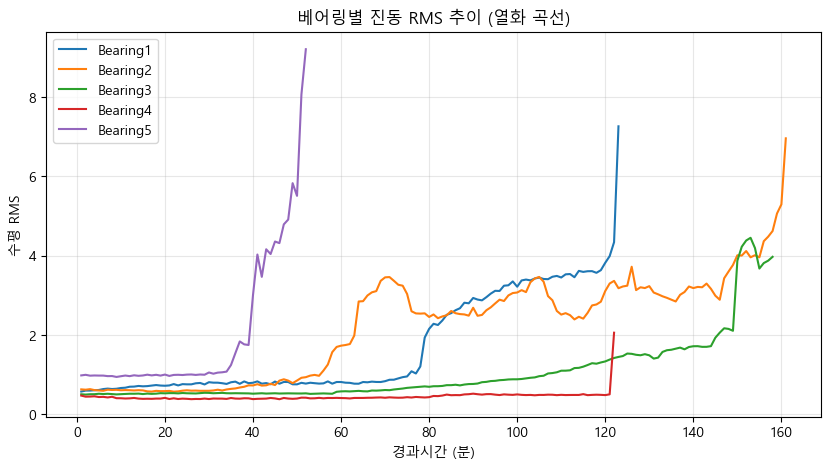

In [ ]:
# 2. 데이터 로드(features.csv)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('features.csv')

# 베어링별 RMS가 시간 따라 오르는지 (열화 신호 확인)
plt.figure(figsize=(10, 5))
for b, g in df.groupby('bearing'):
    plt.plot(g['op_minute'], g['h_rms'], label=b)
plt.xlabel('경과시간 (분)')
plt.ylabel('수평 RMS')
plt.title('베어링별 진동 RMS 추이 (열화 곡선)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

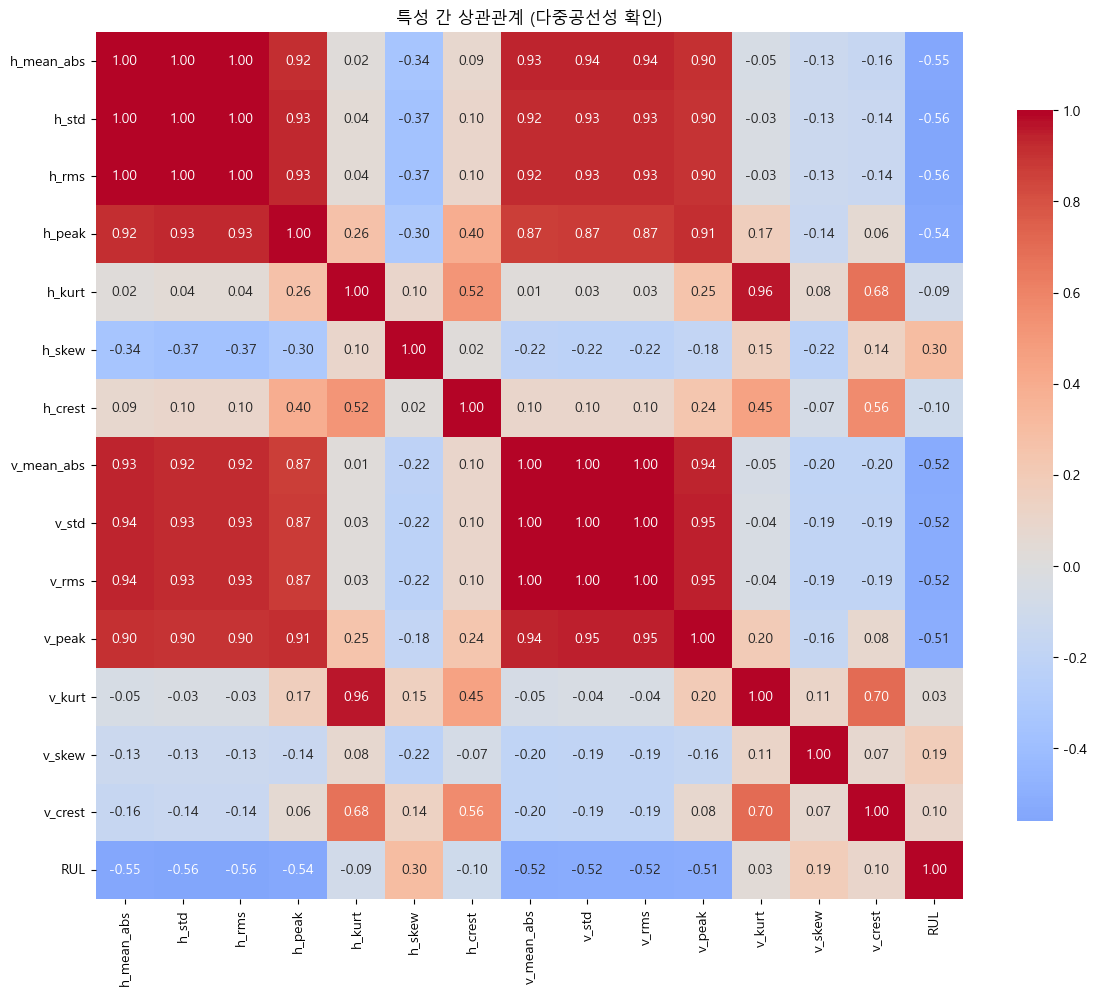

=== RUL과의 상관계수 (절대값 큰 순) ===
h_rms        -0.558706
h_std        -0.558436
h_mean_abs   -0.549788
h_peak       -0.543674
v_mean_abs   -0.524300
v_rms        -0.519850
v_std        -0.519803
v_peak       -0.505761
h_skew        0.300485
v_skew        0.186356
h_crest      -0.104846
v_crest       0.099861
h_kurt       -0.086412
v_kurt        0.034516
Name: RUL, dtype: float64


In [ ]:
# 3. EDA-수치형 히트맵

# 진동 특성만 (bearing 문자열, op_minute 제외)
feat_cols = [c for c in df.columns if c.startswith(('h_', 'v_'))]
corr = df[feat_cols + ['RUL']].corr()

# 히트맵
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('특성 간 상관관계 (다중공선성 확인)')
plt.tight_layout()
plt.show()

# RUL과의 상관관계 순위
rul_corr = corr['RUL'].drop('RUL').sort_values(key=abs, ascending=False)
print("=== RUL과의 상관계수 (절대값 큰 순) ===")
print(rul_corr)

In [12]:
# 4. 데이터 분할

# 다중공선성 정리 후 최종 특성 4개
features = ['h_rms', 'h_kurt', 'h_skew', 'h_crest']
target = 'RUL'

# 시계열 → train_test_split 대신 slice!!! 한 베어링을 통째로 테스트 ㄱㄱ
test_bearing = 'Bearing1'
train_df = df[df['bearing'] != test_bearing]   # 베어링 4개 학습
test_df  = df[df['bearing'] == test_bearing]    # 1개 통째로 테스트(시간순 보존)

X_train, y_train = train_df[features], train_df[target]
X_test,  y_test  = test_df[features],  test_df[target]
print(f"학습 {len(X_train)}행(4개) / 테스트 {len(X_test)}행({test_bearing})")

학습 493행(4개) / 테스트 123행(Bearing1)


In [13]:
# 5. 성능 평가
models = {
    '선형회귀':     LinearRegression(),
    '다항회귀(2차)': make_pipeline(PolynomialFeatures(2), LinearRegression()),
    '랜덤포레스트':  RandomForestRegressor(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    results.append({'모델': name,
                    'R2':   r2_score(y_test, pred),
                    'MSE':  mse,
                    'RMSE': np.sqrt(mse),
                    'MAE':  mean_absolute_error(y_test, pred)})

print(pd.DataFrame(results).to_string(index=False))

      모델       R2        MSE      RMSE       MAE
    선형회귀 0.702501 375.047563 19.366145 15.269372
다항회귀(2차) 0.234415 965.147486 31.066823 23.558166
  랜덤포레스트 0.514706 611.793437 24.734459 19.085041


In [15]:
# 6. 랜덤포레스트 모델 학습

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


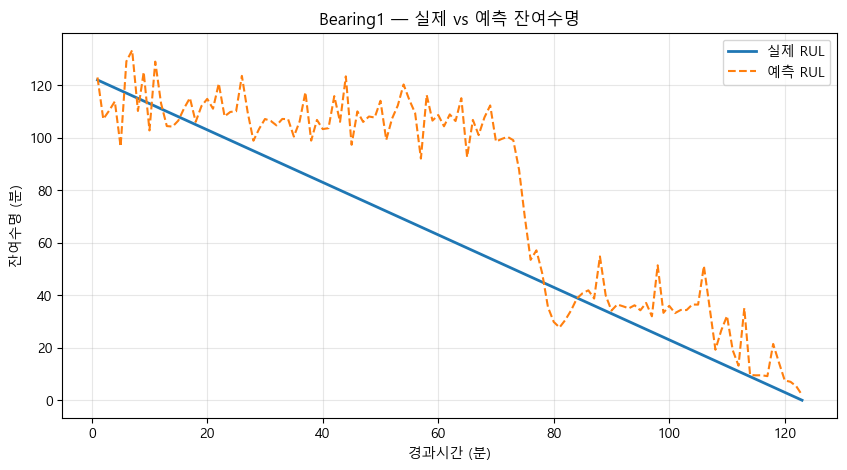

In [ ]:
# 7. Bearing1 실제 vs 예측 잔여수명
pred = rf.predict(X_test)

plt.figure(figsize=(10, 5))
plt.plot(test_df['op_minute'], y_test.values, label='실제 RUL', linewidth=2)
plt.plot(test_df['op_minute'], pred, label='예측 RUL', linestyle='--')
plt.xlabel('경과시간 (분)'); plt.ylabel('잔여수명 (분)')
plt.title(f'{test_bearing} — 실제 vs 예측 잔여수명')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# 8. 총 5ea 타입 베어링별 교차검증

bearings = df['bearing'].unique()

def make_models():
    return {
        '선형회귀':     LinearRegression(),
        '다항회귀(2차)': make_pipeline(PolynomialFeatures(2), LinearRegression()),
        '랜덤포레스트':  RandomForestRegressor(n_estimators=100, random_state=42),
    }

records = []
for test_b in bearings:                      # 베어링 하나씩 테스트로 slice
    train_df = df[df['bearing'] != test_b]
    test_df  = df[df['bearing'] == test_b]
    Xtr, ytr = train_df[features], train_df[target]
    Xte, yte = test_df[features],  test_df[target]
    for name, model in make_models().items():
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)
        records.append({'테스트베어링': test_b, '모델': name,
                        'R2': r2_score(yte, pred),
                        'MAE': mean_absolute_error(yte, pred)})

res = pd.DataFrame(records)
print("=== 베어링별 R2 ===")
print(res.pivot(index='테스트베어링', columns='모델', values='R2').round(3))
print("\n=== 모델별 평균 (베어링 5개) ===")
print(res.groupby('모델')[['R2', 'MAE']].mean().round(3))

=== 베어링별 R2 ===
모델         다항회귀(2차)  랜덤포레스트    선형회귀
테스트베어링                             
Bearing1      0.234   0.515   0.703
Bearing2     -0.331   0.032   0.056
Bearing3      0.057  -1.619   0.168
Bearing4 -14098.306  -6.179 -15.295
Bearing5    -14.920  -3.994  -8.770

=== 모델별 평균 (베어링 5개) ===
                R2      MAE
모델                         
다항회귀(2차) -2822.653  119.030
랜덤포레스트      -2.249   46.560
선형회귀        -4.628   37.761


In [ ]:
# 9. 타깃 정규화 후 재검증

# 핵심: 베어링 총수명으로 RUL 정규화 → '남은 수명 비율(%)'
df['N'] = df.groupby('bearing')['op_minute'].transform('max')   # 각 베어링 총수명
df['RUL_pct'] = df['RUL'] / df['N'] * 100                        # 0~100%
target = 'RUL_pct'

bearings = df['bearing'].unique()
def make_models():
    return {
        '선형회귀':    LinearRegression(),
        '랜덤포레스트': RandomForestRegressor(n_estimators=100, random_state=42),
    }

records = []
for test_b in bearings:                       # 베어링 하나씩 slice 테스트
    tr = df[df['bearing'] != test_b]
    te = df[df['bearing'] == test_b]
    for name, model in make_models().items():
        model.fit(tr[features], tr[target])
        pred = model.predict(te[features])
        records.append({'테스트베어링': test_b, '모델': name,
                        'R2':  r2_score(te[target], pred),
                        'MAE': mean_absolute_error(te[target], pred)})

res = pd.DataFrame(records)
print("=== 베어링별 R2 (정규화 RUL%) ===")
print(res.pivot(index='테스트베어링', columns='모델', values='R2').round(3))
print("\n=== 모델별 평균 ===")
print(res.groupby('모델')[['R2', 'MAE']].mean().round(3))

=== 베어링별 R2 (정규화 RUL%) ===
모델        랜덤포레스트   선형회귀
테스트베어링                 
Bearing1   0.758  0.299
Bearing2   0.413  0.474
Bearing3  -1.598  0.364
Bearing4  -2.359 -4.319
Bearing5   0.276  0.497

=== 모델별 평균 ===
           R2     MAE
모델                   
랜덤포레스트 -0.502  26.646
선형회귀   -0.537  21.409


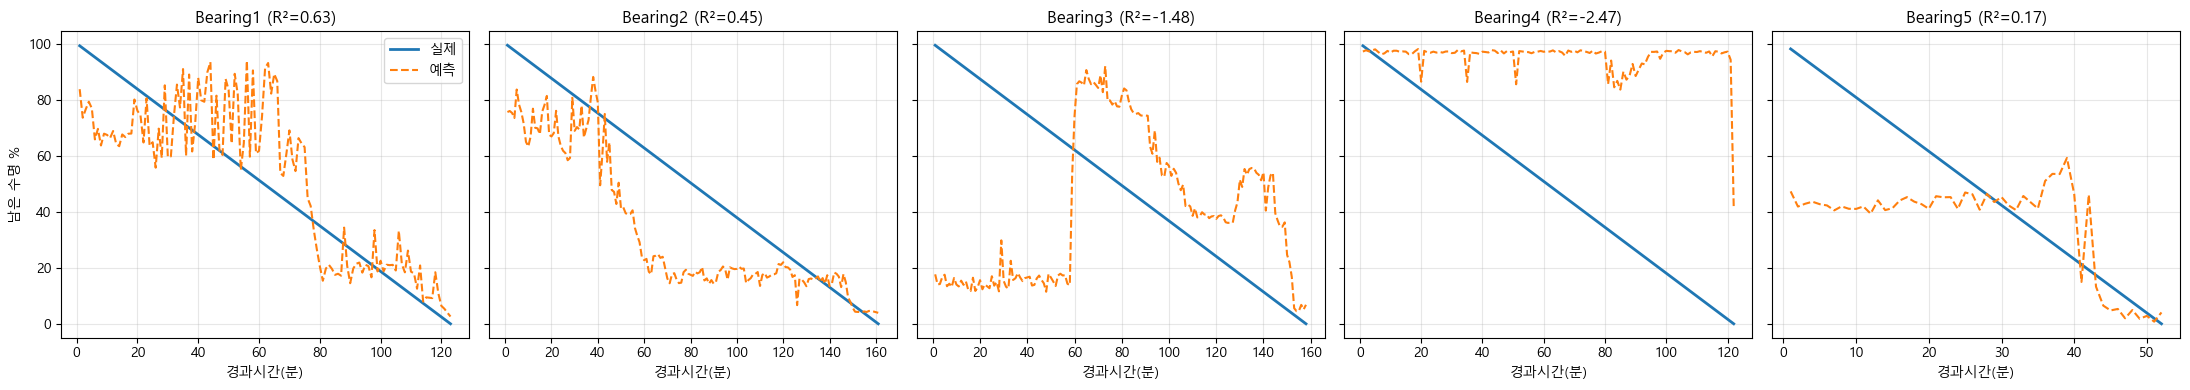

In [19]:
# 10. 총 5ea 타입 Bearing 실제 vs 예측 잔여수명

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
for ax, test_b in zip(axes, bearings):
    tr = df[df['bearing'] != test_b]
    te = df[df['bearing'] == test_b].sort_values('op_minute')
    m = RandomForestRegressor(n_estimators=100, random_state=42).fit(tr[features], tr['RUL_pct'])
    pred = m.predict(te[features])
    ax.plot(te['op_minute'], te['RUL_pct'], label='실제', linewidth=2)
    ax.plot(te['op_minute'], pred, '--', label='예측')
    ax.set_title(f"{test_b} (R²={r2_score(te['RUL_pct'], pred):.2f})")
    ax.set_xlabel('경과시간(분)'); ax.grid(True, alpha=0.3)
axes[0].set_ylabel('남은 수명 %'); axes[0].legend()
plt.tight_layout(); plt.show()

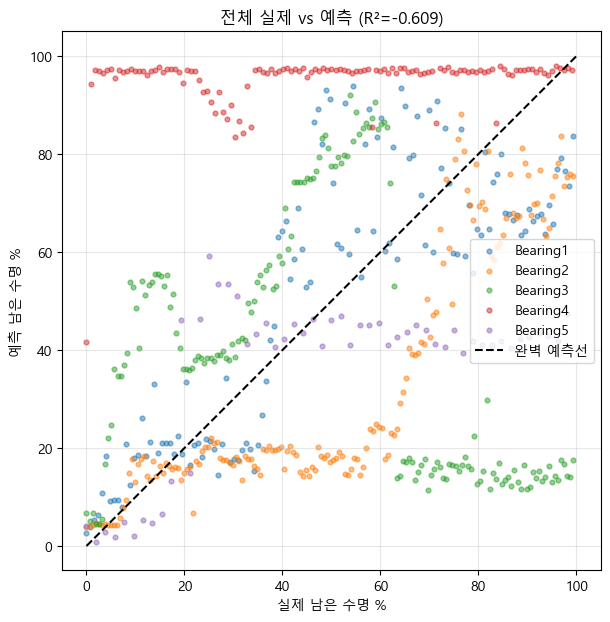

In [20]:
# 11. 전체 실제 vs 예측 산점도

# leave-one-out 예측 전부 모으기
parts = []
for test_b in bearings:
    tr = df[df['bearing'] != test_b]
    te = df[df['bearing'] == test_b].copy()
    m = RandomForestRegressor(n_estimators=100, random_state=42).fit(tr[features], tr['RUL_pct'])
    te['pred'] = m.predict(te[features])
    parts.append(te)
allp = pd.concat(parts)

plt.figure(figsize=(7, 7))
for b, g in allp.groupby('bearing'):
    plt.scatter(g['RUL_pct'], g['pred'], s=12, alpha=0.5, label=b)
plt.plot([0, 100], [0, 100], 'k--', linewidth=1.5, label='완벽 예측선')
plt.xlabel('실제 남은 수명 %'); plt.ylabel('예측 남은 수명 %')
plt.title(f'전체 실제 vs 예측 (R²={r2_score(allp["RUL_pct"], allp["pred"]):.3f})')
plt.legend(); plt.grid(True, alpha=0.3); plt.axis('square')
plt.show()

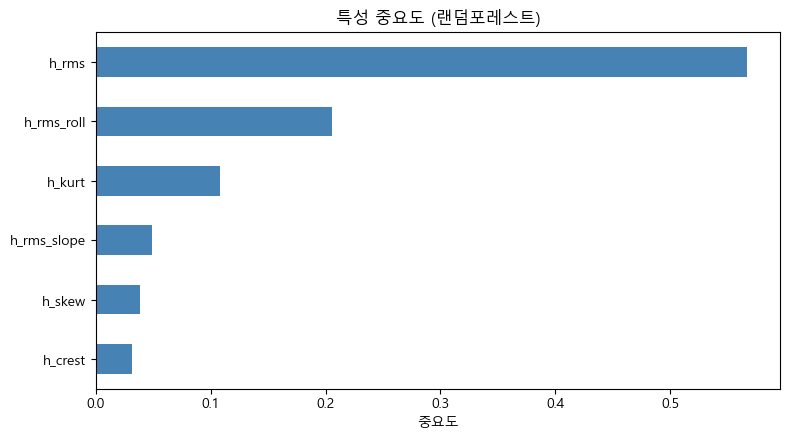

h_rms          0.567318
h_rms_roll     0.205410
h_kurt         0.107820
h_rms_slope    0.049184
h_skew         0.038575
h_crest        0.031692
dtype: float64


In [21]:
# 12. 변수중요도

rf_full = RandomForestRegressor(n_estimators=100, random_state=42)
rf_full.fit(df[features], df['RUL_pct'])   # 전체로 학습

imp = pd.Series(rf_full.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 4.5))
imp.plot(kind='barh', color='steelblue')
plt.xlabel('중요도'); plt.title('특성 중요도 (랜덤포레스트)')
plt.tight_layout(); plt.show()

print(imp.sort_values(ascending=False))

In [26]:
# 13. GridSearchCV로 랜덤포레스트 튜닝

features = ['h_rms', 'h_kurt', 'h_skew', 'h_crest']
X = df[features]
y = df['RUL_pct']
groups = df['bearing']

# 탐색할 하이퍼파라미터 (트리 개수 / 깊이 / 분기당 특성수)
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth':    [4, 8, None],
    'max_features': [2, 3, 4],     # 특성이 4개라 1~4 범위
}

# 핵심: 폴드도 '베어링 단위'로 나눔 = GridSearchCV판 slice (GroupKFold)
gkf = GroupKFold(n_splits=5)

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=gkf, scoring='r2', n_jobs=-1
)
grid.fit(X, y, groups=groups)

print("최적 하이퍼파라미터:", grid.best_params_)
print("최적 교차검증 R²: %.3f" % grid.best_score_)

best_rf = grid.best_estimator_     # 다음 단계(저장/Streamlit)에서 사용

최적 하이퍼파라미터: {'max_depth': 4, 'max_features': 2, 'n_estimators': 200}
최적 교차검증 R²: 0.051
